# Segment classification baselines

## Goal

- Train German GBERT classifiers to label reflection segments.
- The first pipeline is a four-classifier cascade: one binary scope model -> one four-class model for each skill dimension.
- The extension pipeline
  - shares the scope model
  - replaces each skill model with a presence classifier followed by a band classifier.

## Dataset

- Use the canonical `*_scope.csv` and `*_modeling_wide.csv` split files.
- Each row represents one candidate annotation bundle (`candidate_id`), not one unique text segment (`segment_id`).
- A segment can have multiple candidate bundles, so the same text may appear in multiple rows with different candidate labels.
- Keep those rows separate: do not deduplicate by segment or text, and do not merge their labels. These rows are alternative annotations of the same text, not additional unique segments.
- This notebook uses the wide file because each candidate has one row containing all three skill targets.
- The canonical `*_modeling_long.csv` is a reshaped view with three rows per candidate, one per skill dimension; it is not needed for these separate classifiers. All candidates from the same document and author stay in one split.
- Scope has 7,405 train, 1,851 dev, and 943 test candidates; the training classes are imbalanced (349 out-of-scope versus 7,056 in-scope).
- Skill targets are available only for in-scope candidates. Class `0` means the skill dimension is absent; classes `1`, `2`, and `3` are bands A, B, and C. Treat them as categorical classes, not an equally spaced numeric scale.
- Rare bands limit conclusions: situationserfassung band 3 has 21 training examples and none in test; konsequenzen band 3 has 38 training examples and 8 in test.
- The test split contains 24 documents from 8 authors, including the 22 feedback-available reflections. Interpret test results with that cohort composition in mind.

## Experiment versions

1. **Direct multiclass baseline (4 classifiers):** one scope classifier (2 classes) plus three independent skill classifiers (4 classes each: absent, A, B, C). This is the primary fast baseline.
2. **Presence-then-band (7 classifiers):** the same shared scope classifier, plus one binary presence classifier and one three-class band classifier for each of the three skills: 1 scope + 3 presence + 3 band. For each skill, train the presence classifier on all in-scope candidates with known targets (`0` = absent; `1-3` = present), and train its band classifier only on present candidates (A, B, or C). At inference, an absent prediction maps to class `0`; a present prediction uses the corresponding band prediction, mapped to classes `1-3`. This tests whether separating presence from band prediction helps, at the cost of three additional classifiers and smaller band-training sets.

- Both versions use the same GBERT encoder and segment text. 
- Training is opt-in below because it downloads the model and trains multiple heads. 
- Choose hyperparameters on dev only; reserve test for final reporting. 
- Report macro-F1 and per-class precision/recall/F1, and distinguish skill performance on gold in-scope rows from the end-to-end pipeline where scope mistakes can propagate. 
- Out-of-scope is a separate end-to-end outcome, not skill class 0.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from reflection_assessment_feedback.experiment_config import load_experiment_config

PROJECT_ROOT = Path.cwd().resolve()
assert PROJECT_ROOT.name == "prebi_v1", "Run this notebook from the prebi_v1 project root."
EXPERIMENT_CONFIG = load_experiment_config()
SPLIT_DIR = PROJECT_ROOT / EXPERIMENT_CONFIG["paths"]["provisional_split_directory"]
SPLITS = tuple(EXPERIMENT_CONFIG["dataset"]["split_names"])
SKILLS = EXPERIMENT_CONFIG["labels"]["skill_targets"]

wide_data = {
    split: pd.read_csv(SPLIT_DIR / f"provisional_{split}_modeling_wide.csv")
    for split in SPLITS
}
scope_data = {
    split: pd.read_csv(SPLIT_DIR / f"provisional_{split}_scope.csv")
    for split in SPLITS
}

for split in SPLITS:
    assert wide_data[split]["candidate_id"].is_unique
    assert scope_data[split]["candidate_id"].is_unique
    assert set(wide_data[split]["candidate_id"]) == set(scope_data[split]["candidate_id"])
    in_scope = wide_data[split].loc[wide_data[split]["component"] == "in_scope"]
    assert in_scope[list(SKILLS.values())].notna().all().all()

print(f"PyTorch: {torch.__version__}; Transformers: {transformers.__version__}")
pd.DataFrame(
    {
        split: {
            "scope candidates": len(scope_data[split]),
            "in-scope candidates": int((wide_data[split]["component"] == "in_scope").sum()),
        }
        for split in SPLITS
    }
)

/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.14.0; Transformers: 4.57.6


,train,dev,test
scope candidates,7107,1823,905
in-scope candidates,6765,1739,874


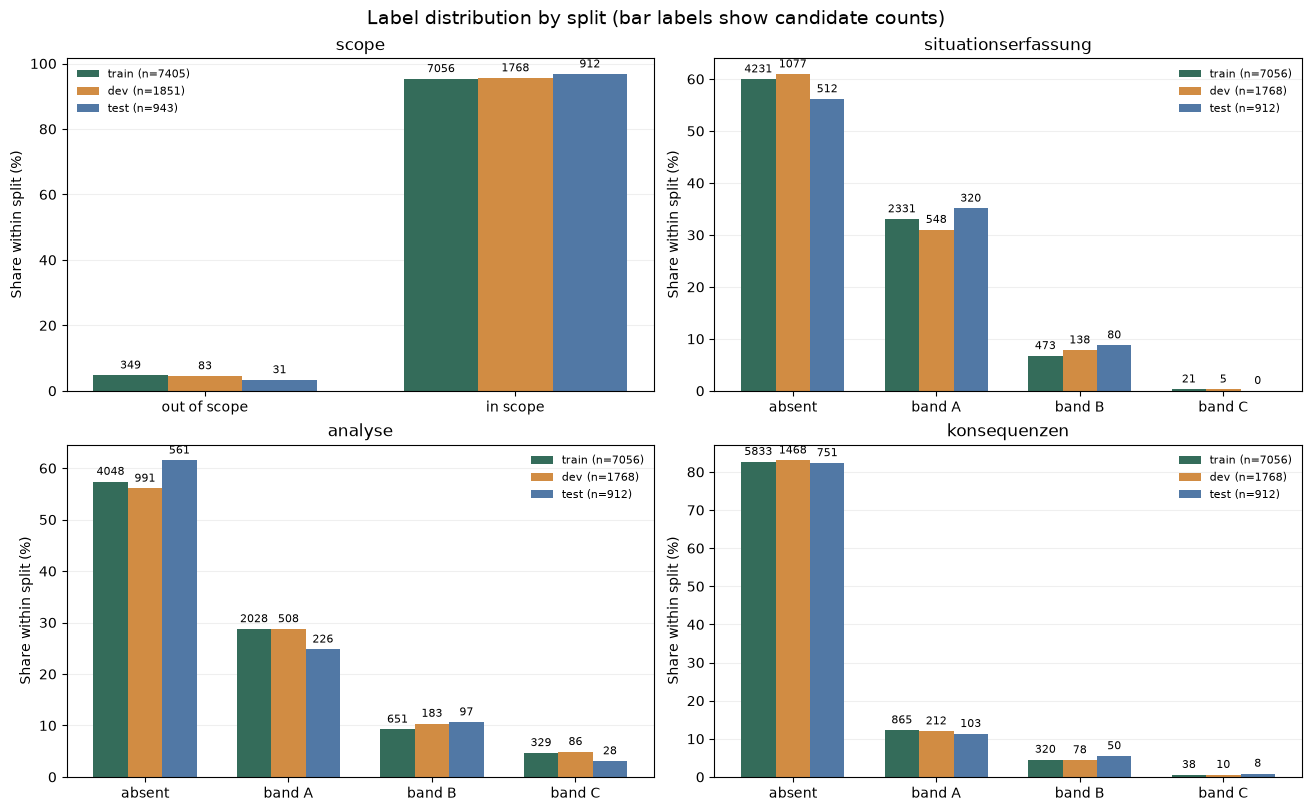

In [2]:
LABELS = {
    "scope": ["out of scope", "in scope"],
    **{
        skill: ["absent", "band A", "band B", "band C"]
        for skill in SKILLS
    },
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
plot_tasks = ["scope", *SKILLS]
colors = {"train": "#346C5A", "dev": "#D18C43", "test": "#5178A5"}

for axis, task in zip(axes.flat, plot_tasks):
    split_counts = {}
    for split in SPLITS:
        if task == "scope":
            labels = scope_data[split]["scope_target"].astype(int)
        else:
            rows = wide_data[split].loc[wide_data[split]["component"] == "in_scope"]
            labels = rows[SKILLS[task]].astype(int)
        split_counts[split] = labels.value_counts().reindex(range(len(LABELS[task])), fill_value=0)

    positions = np.arange(len(LABELS[task]))
    width = 0.24
    for split_index, split in enumerate(SPLITS):
        counts = split_counts[split]
        percentages = counts / counts.sum() * 100
        offset = (split_index - 1) * width
        bars = axis.bar(
            positions + offset,
            percentages,
            width,
            label=f"{split} (n={int(counts.sum())})",
            color=colors[split],
        )
        for bar, count, percentage in zip(bars, counts, percentages):
            axis.annotate(
                f"{int(count)}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    axis.set_title(task)
    axis.set_xticks(positions, LABELS[task])
    axis.set_ylabel("Share within split (%)")
    axis.grid(axis="y", alpha=0.2)
    axis.set_axisbelow(True)
    axis.legend(frameon=False, fontsize=8)

fig.suptitle("Label distribution by split (bar labels show candidate counts)", fontsize=14)
plt.show()

## Training setup

- The chart shows the within-split percentage for each class; labels above bars are raw candidate counts. 
- The skill panels use in-scope candidates only. 
- The weighted loss below uses the square root of inverse class frequency, capped and normalized, to give rare labels more influence without the extreme weights of fully balanced sampling. 
- Check dev macro-F1 and per-class scores before drawing conclusions about the rare bands.

In [2]:
import gc
import json
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from reflection_assessment_feedback.experiment_config import (
    experiment_config_sha256,
    load_experiment_config,
)

EXPERIMENT_CONFIG = load_experiment_config()
CLASSIFIER_CONFIG = EXPERIMENT_CONFIG["classifier"]
MODEL_NAME = CLASSIFIER_CONFIG["model_name"]
MODEL_REVISION = CLASSIFIER_CONFIG["model_revision"] or None
MAX_LENGTH = CLASSIFIER_CONFIG["max_length"]
BATCH_SIZE = CLASSIFIER_CONFIG["batch_size"]
EPOCHS = CLASSIFIER_CONFIG["epochs"]
LEARNING_RATE = CLASSIFIER_CONFIG["learning_rate"]
WEIGHT_DECAY = CLASSIFIER_CONFIG["weight_decay"]
EARLY_STOPPING_PATIENCE = CLASSIFIER_CONFIG["early_stopping_patience"]
EARLY_STOPPING_MIN_DELTA = CLASSIFIER_CONFIG["early_stopping_min_delta"]
CLASS_WEIGHT_MIN = CLASSIFIER_CONFIG["class_weight_min"]
CLASS_WEIGHT_MAX = CLASSIFIER_CONFIG["class_weight_max"]
WARMUP_RATIO = CLASSIFIER_CONFIG["warmup_ratio"]
GRADIENT_CLIP_NORM = CLASSIFIER_CONFIG["gradient_clip_norm"]
SEED = CLASSIFIER_CONFIG["seed"]
RUN_DIR = PROJECT_ROOT / EXPERIMENT_CONFIG["paths"]["classifier_checkpoints"]
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"Training device: {DEVICE}")


def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_data_loader(frame, tokenizer, label_col=None, shuffle=False):
    texts = frame["text"].fillna("").astype(str).tolist()
    labels = None if label_col is None else frame[label_col].astype(int).to_numpy()

    def collate_rows(row_indices):
        indices = [int(index) for index in row_indices]
        batch_texts = [texts[index] for index in indices]
        batch = tokenizer(
            batch_texts,
            truncation=True,
            max_length=MAX_LENGTH,
            padding=True,
            return_tensors="pt",
        )
        batch = {key: value.to(DEVICE) for key, value in batch.items()}
        if labels is not None:
            batch["labels"] = torch.tensor(labels[indices], dtype=torch.long, device=DEVICE)
        return batch

    return DataLoader(
        torch.arange(len(texts)),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        collate_fn=collate_rows,
    )


def predict_from_loader(model, data_loader):
    model.eval()
    predictions = []
    gold_labels = []
    with torch.inference_mode():
        for batch in data_loader:
            labels = batch.pop("labels", None)
            logits = model(**batch).logits
            predictions.extend(logits.argmax(dim=1).cpu().numpy())
            if labels is not None:
                gold_labels.extend(labels.cpu().numpy())
    return np.asarray(predictions), np.asarray(gold_labels, dtype=int)


def fit_gbert_classifier(train_frame, dev_frame, label_col, num_labels, run_name, tokenizer):
    set_seed()
    train_labels = train_frame[label_col].astype(int).to_numpy()
    class_counts = np.bincount(train_labels, minlength=num_labels)
    if len(class_counts) != num_labels or (class_counts == 0).any():
        raise ValueError(f"Training data for {run_name} is missing one or more classes: {class_counts}")

    train_loader = make_data_loader(train_frame, tokenizer, label_col, shuffle=True)
    dev_loader = make_data_loader(dev_frame, tokenizer, label_col)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        revision=MODEL_REVISION,
        num_labels=num_labels,
    ).to(DEVICE)
    model.config.problem_type = "single_label_classification"

    class_weights = np.sqrt(class_counts.sum() / class_counts)
    class_weights = class_weights / class_weights.mean()
    class_weights = np.clip(class_weights, CLASS_WEIGHT_MIN, CLASS_WEIGHT_MAX)
    class_weights = class_weights / class_weights.mean()
    loss_function = torch.nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
    )
    print(
        f"{run_name}: weighted CrossEntropyLoss, "
        f"class counts={class_counts.tolist()}, "
        f"class weights={class_weights.round(3).tolist()}"
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    total_steps = max(1, len(train_loader) * EPOCHS)
    warmup_steps = max(1, int(total_steps * WARMUP_RATIO))

    def learning_rate_scale(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        return max(0.0, (total_steps - step) / max(1, total_steps - warmup_steps))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, learning_rate_scale)
    checkpoint_path = RUN_DIR / f"{run_name}.pt"
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    best_macro_f1 = -1.0
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        batch_losses = []
        with tqdm(train_loader, desc=f"{run_name} epoch {epoch}/{EPOCHS}", unit="batch") as progress:
            for batch in progress:
                labels = batch.pop("labels")
                optimizer.zero_grad(set_to_none=True)
                logits = model(**batch).logits
                loss = loss_function(logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRADIENT_CLIP_NORM)
                optimizer.step()
                scheduler.step()
                batch_losses.append(loss.item())
                progress.set_postfix(train_loss=f"{np.mean(batch_losses):.4f}")

        dev_predictions, dev_labels = predict_from_loader(model, dev_loader)
        dev_macro_f1 = f1_score(
            dev_labels,
            dev_predictions,
            labels=np.arange(num_labels),
            average="macro",
            zero_division=0,
        )
        history.append(
            {
                "epoch": epoch,
                "train_loss": float(np.mean(batch_losses)),
                "dev_macro_f1": float(dev_macro_f1),
            }
        )
        print(
            f"{run_name}: epoch {epoch}/{EPOCHS}, "
            f"train loss={history[-1]['train_loss']:.4f}, dev macro-F1={dev_macro_f1:.4f}"
        )

        if dev_macro_f1 > best_macro_f1 + EARLY_STOPPING_MIN_DELTA:
            best_macro_f1 = float(dev_macro_f1)
            epochs_without_improvement = 0
            torch.save(
                {key: value.detach().cpu() for key, value in model.state_dict().items()},
                checkpoint_path,
            )
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                break

    del model, optimizer, scheduler, train_loader, dev_loader
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    result = {
        "checkpoint": str(checkpoint_path),
        "num_labels": num_labels,
        "history": history,
        "best_dev_macro_f1": best_macro_f1,
        "experiment_config_sha256": experiment_config_sha256(),
        "experiment_config": EXPERIMENT_CONFIG,
    }
    (RUN_DIR / f"{run_name}.json").write_text(json.dumps(result, indent=2))
    return result


def fit_or_load_gbert_classifier(train_frame, dev_frame, label_col, num_labels, run_name, tokenizer):
    metadata_path = RUN_DIR / f"{run_name}.json"
    if REUSE_COMPLETED_RUNS and metadata_path.is_file():
        result = json.loads(metadata_path.read_text())
        if result["num_labels"] != num_labels or not Path(result["checkpoint"]).is_file():
            raise ValueError(f"Incomplete or incompatible saved run: {run_name}")
        print(f"{run_name}: loading completed run (dev macro-F1={result['best_dev_macro_f1']:.4f})")
        return result
    return fit_gbert_classifier(train_frame, dev_frame, label_col, num_labels, run_name, tokenizer)


def predict_gbert(model_info, frame, tokenizer):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        revision=MODEL_REVISION,
        num_labels=model_info["num_labels"],
    )
    state = torch.load(model_info["checkpoint"], map_location="cpu", weights_only=True)
    model.load_state_dict(state)
    model.to(DEVICE)
    data_loader = make_data_loader(frame, tokenizer)
    predictions, _ = predict_from_loader(model, data_loader)
    del model, data_loader
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    return predictions

Training device: mps


In [3]:
import hashlib
from datetime import datetime, timezone
import shutil

SPLIT_SHA256 = {
    f'{split}_{view}': hashlib.sha256(
        (SPLIT_DIR / f'provisional_{split}_{view}.csv').read_bytes()
    ).hexdigest()
    for split in SPLITS for view in ('scope', 'modeling_wide')
}
for left, right in [('train', 'dev'), ('train', 'test'), ('dev', 'test')]:
    for column in ('document_id', 'author_id', 'segment_id'):
        assert not (set(wide_data[left][column]) & set(wide_data[right][column])), f'{column} leakage'
for split in SPLITS:
    assert scope_data[split]['scope_target_known'].all()
    assert scope_data[split]['scope_target'].isin([0, 1]).all()
    assert not wide_data[split]['scope_unresolved'].any()
    assert wide_data[split]['text'].fillna('').str.strip().str.len().ge(10).all()
    in_scope = wide_data[split]['scope_target'].eq(1)
    for skill, target in SKILLS.items():
        assert wide_data[split].loc[in_scope, f'known_{skill}'].all()
        assert wide_data[split].loc[in_scope, target].isin([0, 1, 2, 3]).all()

RETRAIN_RUN_ID = datetime.now(timezone.utc).strftime('retrain-%Y%m%dT%H%M%S%fZ')
RUN_DIR = PROJECT_ROOT / 'artifacts' / 'segment-classification' / RETRAIN_RUN_ID
assert shutil.disk_usage(PROJECT_ROOT).free > 6 * 1024**3, 'Need at least 6 GiB free for new checkpoints.'
RUN_DIR.mkdir(parents=True, exist_ok=False)

_original_fit_gbert_classifier = fit_gbert_classifier

def fit_gbert_classifier(train_frame, dev_frame, label_col, num_labels, run_name, tokenizer):
    result = _original_fit_gbert_classifier(
        train_frame, dev_frame, label_col, num_labels, run_name, tokenizer,
    )
    result.update({
        'split_sha256': SPLIT_SHA256,
        'training_rows': len(train_frame), 'development_rows': len(dev_frame),
        'training_run_id': RETRAIN_RUN_ID,
        'selection_split': 'dev', 'test_used_for_training': False,
    })
    (RUN_DIR / f'{run_name}.json').write_text(json.dumps(result, indent=2), encoding='utf-8')
    return result

print('New checkpoint directory:', RUN_DIR)
print('Split hashes and label-quality checks ready; original checkpoints are unchanged.')

New checkpoint directory: /Users/quynguyen/Documents/CodingProjects/prebi_v1/artifacts/segment-classification/retrain-20261003T125604532027Z
Split hashes and label-quality checks ready; original checkpoints are unchanged.


In [4]:
from transformers import AutoConfig


def load_gbert_assets():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
    model_config = AutoConfig.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
    if model_config.model_type != "bert":
        raise ValueError(f"Expected a BERT config for {MODEL_NAME}, got {model_config.model_type!r}")
    return tokenizer, model_config


PREPARE_MODEL_ASSETS = True
tokenizer = None
model_config = None
if PREPARE_MODEL_ASSETS:
    tokenizer, model_config = load_gbert_assets()
    print(f"GBERT tokenizer and {model_config.model_type} config are ready; Hub cache will be reused.")

GBERT tokenizer and bert config are ready; Hub cache will be reused.


## Train and evaluate

The current filtered split has 7,107 train, 1,823 dev, and 905 test scope candidates. In-scope skill counts are 6,765 / 1,739 / 874. Unresolved scope and unknown applicable skill labels are excluded by the canonical export; the retraining preflight verifies labels, text quality, and author/document/segment separation.

Run the isolated-retraining setup after defining training functions. It creates a new timestamped directory under `artifacts/segment-classification/`, preserves existing checkpoints, and records SHA-256 hashes of the scope and wide split files in every completed model. Do not rerun that setup midway through training: it creates another run directory.

Use the group switches to train scope, direct, and presence/band models. Checkpoints are selected on dev macro-F1 only. The validation cell after hierarchical training verifies all ten checkpoints and saves `dev-summary.csv` and `run-manifest.json`, including checkpoint hashes.

Completed current-split run: `artifacts/segment-classification/retrain-20261003T125604532027Z`. All ten models finished and were validated; no test evaluation was executed during retraining. The shared experiment config still points to the previous checkpoint directory, preserving existing downstream workflows. To compare the new direct cascade in `05_segment_evaluation.ipynb`, set `GBERT_CHECKPOINT_DIR` to this run directory before executing comparison.

The final cell evaluates test only when `RUN_EVALUATION=True`. Do not execute it until models and settings have been frozen. Existing test results elsewhere describe the previous checkpoints, not this retrained run.

In [5]:
RUN_SCOPE = True
RUN_DIRECT = True
RUN_HIERARCHICAL = True
REUSE_COMPLETED_RUNS = False
training_results = {"scope": {}, "direct": {}, "presence": {}, "band": {}}
scope_frames = {
    split: scope_data[split].loc[scope_data[split]["scope_target_known"]].copy()
    for split in SPLITS
}

if RUN_SCOPE:
    if tokenizer is None:
        tokenizer, model_config = load_gbert_assets()
    training_results["scope"] = fit_or_load_gbert_classifier(
        scope_frames["train"],
        scope_frames["dev"],
        label_col="scope_target",
        num_labels=2,
        run_name="scope",
        tokenizer=tokenizer,
    )
else:
    print("Scope training skipped. Set RUN_SCOPE = True to train or load it.")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


scope: weighted CrossEntropyLoss, class counts=[342, 6765], class weights=[1.531, 0.469]


scope epoch 1/4: 100%|██████████| 889/889 [05:09<00:00,  2.87batch/s, train_loss=0.3498]


scope: epoch 1/4, train loss=0.3498, dev macro-F1=0.8080


scope epoch 2/4: 100%|██████████| 889/889 [02:31<00:00,  5.85batch/s, train_loss=0.1713]


scope: epoch 2/4, train loss=0.1713, dev macro-F1=0.8078


scope epoch 3/4: 100%|██████████| 889/889 [02:32<00:00,  5.84batch/s, train_loss=0.0556]


scope: epoch 3/4, train loss=0.0556, dev macro-F1=0.8262


scope epoch 4/4: 100%|██████████| 889/889 [02:32<00:00,  5.83batch/s, train_loss=0.0135]


scope: epoch 4/4, train loss=0.0135, dev macro-F1=0.8412


In [6]:
if RUN_DIRECT:
    if tokenizer is None:
        tokenizer, model_config = load_gbert_assets()
    skill_frames = {
        split: wide_data[split].loc[wide_data[split]["component"] == "in_scope"].copy()
        for split in SPLITS
    }
    for skill, target_col in SKILLS.items():
        training_results["direct"][skill] = fit_or_load_gbert_classifier(
            skill_frames["train"],
            skill_frames["dev"],
            label_col=target_col,
            num_labels=4,
            run_name=f"direct-{skill}",
            tokenizer=tokenizer,
        )
else:
    print("Direct skill training skipped. Set RUN_DIRECT = True to train or load it.")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


direct-situationserfassung: weighted CrossEntropyLoss, class counts=[3980, 2275, 489, 21], class weights=[0.444, 0.444, 0.534, 2.579]


direct-situationserfassung epoch 1/4: 100%|██████████| 846/846 [02:23<00:00,  5.88batch/s, train_loss=0.7331]


direct-situationserfassung: epoch 1/4, train loss=0.7331, dev macro-F1=0.5189


direct-situationserfassung epoch 2/4: 100%|██████████| 846/846 [02:23<00:00,  5.90batch/s, train_loss=0.4741]


...

direct-konsequenzen: epoch 2/4, train loss=0.3563, dev macro-F1=0.5746


direct-konsequenzen epoch 3/4: 100%|██████████| 846/846 [02:22<00:00,  5.93batch/s, train_loss=0.2638]


direct-konsequenzen: epoch 3/4, train loss=0.2638, dev macro-F1=0.5782


direct-konsequenzen epoch 4/4: 100%|██████████| 846/846 [02:23<00:00,  5.91batch/s, train_loss=0.1778]


direct-konsequenzen: epoch 4/4, train loss=0.1778, dev macro-F1=0.5746


In [7]:
if RUN_HIERARCHICAL:
    if tokenizer is None:
        tokenizer, model_config = load_gbert_assets()
    skill_frames = {
        split: wide_data[split].loc[wide_data[split]["component"] == "in_scope"].copy()
        for split in SPLITS
    }
    for skill, target_col in SKILLS.items():
        presence_frames = {}
        band_frames = {}
        for split, frame in skill_frames.items():
            presence_frame = frame.copy()
            presence_frame["presence_label"] = (presence_frame[target_col].astype(int) > 0).astype(int)
            presence_frames[split] = presence_frame
            band_frames[split] = frame.loc[frame[target_col].astype(int) > 0].copy()
            band_frames[split]["band_label"] = band_frames[split][target_col].astype(int) - 1

        training_results["presence"][skill] = fit_or_load_gbert_classifier(
            presence_frames["train"],
            presence_frames["dev"],
            label_col="presence_label",
            num_labels=2,
            run_name=f"presence-{skill}",
            tokenizer=tokenizer,
        )
        training_results["band"][skill] = fit_or_load_gbert_classifier(
            band_frames["train"],
            band_frames["dev"],
            label_col="band_label",
            num_labels=3,
            run_name=f"band-{skill}",
            tokenizer=tokenizer,
        )
else:
    print("Presence/band training skipped. Set RUN_HIERARCHICAL = True to train or load it.")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


presence-situationserfassung: weighted CrossEntropyLoss, class counts=[3980, 2785], class weights=[0.911, 1.089]


presence-situationserfassung epoch 1/4: 100%|██████████| 846/846 [02:24<00:00,  5.85batch/s, train_loss=0.4915]


presence-situationserfassung: epoch 1/4, train loss=0.4915, dev macro-F1=0.7992


presence-situationserfassung epoch 2/4: 100%|██████████| 846/846 [02:25<00:00,  5.83batch/s, train_loss=0.3389]


...

band-konsequenzen: epoch 2/4, train loss=0.5711, dev macro-F1=0.6442


band-konsequenzen epoch 3/4: 100%|██████████| 132/132 [00:22<00:00,  5.87batch/s, train_loss=0.3416]


band-konsequenzen: epoch 3/4, train loss=0.3416, dev macro-F1=0.6689


band-konsequenzen epoch 4/4: 100%|██████████| 132/132 [00:22<00:00,  5.91batch/s, train_loss=0.1958]


band-konsequenzen: epoch 4/4, train loss=0.1958, dev macro-F1=0.6479


In [8]:
completed_models = [('scope', training_results['scope'])]
for group in ('direct', 'presence', 'band'):
    completed_models.extend((f'{group}-{skill}', result) for skill, result in training_results[group].items())
assert len(completed_models) == 10, 'All ten models must finish before run validation.'
run_summary = []
for run_name, result in completed_models:
    assert result['split_sha256'] == SPLIT_SHA256
    assert result['selection_split'] == 'dev' and result['test_used_for_training'] is False
    checkpoint = Path(result['checkpoint'])
    assert checkpoint.parent == RUN_DIR and checkpoint.is_file()
    state = torch.load(checkpoint, map_location='cpu', weights_only=True)
    assert state['classifier.weight'].shape[0] == result['num_labels']
    assert all(torch.isfinite(value).all().item() for value in state.values() if value.is_floating_point())
    del state
    run_summary.append({
        'run': run_name, 'training_rows': result['training_rows'],
        'dev_rows': result['development_rows'], 'best_dev_macro_f1': result['best_dev_macro_f1'],
        'epochs': len(result['history']),
    })
    with checkpoint.open('rb') as checkpoint_file:
        result['checkpoint_sha256'] = hashlib.file_digest(checkpoint_file, 'sha256').hexdigest()
    (RUN_DIR / f'{run_name}.json').write_text(json.dumps(result, indent=2), encoding='utf-8')

pd.DataFrame(run_summary).to_csv(RUN_DIR / 'dev-summary.csv', index=False)
(RUN_DIR / 'run-manifest.json').write_text(json.dumps({
    'training_run_id': RETRAIN_RUN_ID, 'split_sha256': SPLIT_SHA256,
    'selection_split': 'dev', 'test_used_for_training': False,
    'models': {name: {'checkpoint_sha256': result['checkpoint_sha256'], 'num_labels': result['num_labels']}
               for name, result in completed_models},
}, indent=2), encoding='utf-8')
display(pd.DataFrame(run_summary).round(4))
print('All ten checkpoint tensors and split fingerprints validated. Test evaluation was not run.')

,run,training_rows,dev_rows,best_dev_macro_f1,epochs
0,scope,7107,1823,0.8412,4
1,direct-situationserfassung,6765,1739,0.5341,4
2,direct-analyse,6765,1739,0.7020,4
3,direct-konsequenzen,6765,1739,0.5782,4
4,presence-situationserfassung,6765,1739,0.8159,4
5,presence-analyse,6765,1739,0.7991,4
6,presence-konsequenzen,6765,1739,0.9102,3
7,band-situationserfassung,2785,673,0.5637,4
8,band-analyse,2928,775,0.7563,4
9,band-konsequenzen,1052,291,0.6689,4


All ten checkpoint tensors and split fingerprints validated. Test evaluation was not run.


In [17]:
def report_task(name, gold, predictions, labels, target_names):
    summary = {
        "task": name,
        "n": int(len(gold)),
        "accuracy": float(accuracy_score(gold, predictions)),
        "macro_f1": float(
            f1_score(gold, predictions, labels=labels, average="macro", zero_division=0)
        ),
        "weighted_f1": float(
            f1_score(gold, predictions, labels=labels, average="weighted", zero_division=0)
        ),
    }
    print(name)
    print(
        classification_report(
            gold,
            predictions,
            labels=labels,
            target_names=target_names,
            zero_division=0,
        )
    )
    print("Confusion matrix (gold rows, predicted columns):")
    print(confusion_matrix(gold, predictions, labels=labels))
    return summary


RUN_EVALUATION = True
if RUN_EVALUATION:
    missing = [
        name for name, models in training_results.items()
        if not models or (name != "scope" and set(models) != set(SKILLS))
    ]
    if missing:
        raise ValueError(f"Train or load all models before test evaluation; missing: {missing}")
    test_scope = scope_frames["test"].reset_index(drop=True)
    test_wide = wide_data["test"].reset_index(drop=True).copy()
    scope_predictions = predict_gbert(
        training_results["scope"],
        test_scope,
        tokenizer,
    )
    scope_gold = test_scope["scope_target"].astype(int).to_numpy()
    evaluation_rows = [
        report_task("scope", scope_gold, scope_predictions, [0, 1], LABELS["scope"])
    ]

    scope_prediction_by_candidate = pd.Series(
        scope_predictions,
        index=test_scope["candidate_id"],
    )
    scope_gold_by_candidate = test_scope.set_index("candidate_id")["scope_target"].astype(int)
    test_wide["gold_scope"] = test_wide["candidate_id"].map(scope_gold_by_candidate).astype(int)
    test_wide["predicted_scope"] = test_wide["candidate_id"].map(scope_prediction_by_candidate).astype(int)
    end_to_end_labels = ["out of scope", "absent", "band A", "band B", "band C"]

    for skill, target_col in SKILLS.items():
        in_scope_test = test_wide.loc[test_wide["gold_scope"] == 1].copy().reset_index(drop=True)
        gold_skill = in_scope_test[target_col].astype(int).to_numpy()

        direct_predictions = predict_gbert(
            training_results["direct"][skill],
            in_scope_test,
            tokenizer,
        )
        evaluation_rows.append(
            report_task(
                f"{skill} direct (gold in-scope)",
                gold_skill,
                direct_predictions,
                [0, 1, 2, 3],
                LABELS[skill],
            )
        )

        presence_predictions = predict_gbert(
            training_results["presence"][skill],
            in_scope_test,
            tokenizer,
        )
        band_predictions = predict_gbert(
            training_results["band"][skill],
            in_scope_test,
            tokenizer,
        )
        hierarchical_predictions = np.where(
            presence_predictions == 0,
            0,
            band_predictions + 1,
        )
        evaluation_rows.append(
            report_task(
                f"{skill} presence-then-band (gold in-scope)",
                gold_skill,
                hierarchical_predictions,
                [0, 1, 2, 3],
                LABELS[skill],
            )
        )

        predicted_in_scope = test_wide.loc[test_wide["predicted_scope"] == 1].copy()
        end_to_end_gold = np.zeros(len(test_wide), dtype=int)
        end_to_end_direct = np.zeros(len(test_wide), dtype=int)
        end_to_end_hierarchical = np.zeros(len(test_wide), dtype=int)
        gold_in_scope_mask = test_wide["gold_scope"].to_numpy() == 1
        end_to_end_gold[gold_in_scope_mask] = test_wide.loc[gold_in_scope_mask, target_col].astype(int) + 1

        direct_all_predictions = predict_gbert(
            training_results["direct"][skill],
            predicted_in_scope,
            tokenizer,
        )
        predicted_scope_mask = test_wide["predicted_scope"].to_numpy() == 1
        end_to_end_direct[predicted_scope_mask] = direct_all_predictions + 1

        presence_all_predictions = predict_gbert(
            training_results["presence"][skill],
            predicted_in_scope,
            tokenizer,
        )
        band_all_predictions = predict_gbert(
            training_results["band"][skill],
            predicted_in_scope,
            tokenizer,
        )
        end_to_end_hierarchical[predicted_scope_mask] = np.where(
            presence_all_predictions == 0,
            1,
            band_all_predictions + 2,
        )

        evaluation_rows.append(
            report_task(
                f"{skill} direct (end-to-end)",
                end_to_end_gold,
                end_to_end_direct,
                [0, 1, 2, 3, 4],
                end_to_end_labels,
            )
        )
        evaluation_rows.append(
            report_task(
                f"{skill} presence-then-band (end-to-end)",
                end_to_end_gold,
                end_to_end_hierarchical,
                [0, 1, 2, 3, 4],
                end_to_end_labels,
            )
        )

    evaluation_summary = pd.DataFrame(evaluation_rows)
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    evaluation_summary.to_csv(RUN_DIR / "test-summary.csv", index=False)
    print(evaluation_summary.to_string(index=False))
else:
    print("Test evaluation skipped. Set RUN_EVALUATION = True after model selection.")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


scope
              precision    recall  f1-score   support

out of scope       0.73      0.52      0.60        31
    in scope       0.98      0.99      0.99       912

    accuracy                           0.98       943
   macro avg       0.86      0.75      0.80       943
weighted avg       0.98      0.98      0.98       943

Confusion matrix (gold rows, predicted columns):
[[ 16  15]
 [  6 906]]


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


situationserfassung direct (gold in-scope)
              precision    recall  f1-score   support

      absent       0.83      0.90      0.86       512
      band A       0.83      0.75      0.79       320
      band B       0.60      0.46      0.52        80
      band C       0.00      0.00      0.00         0

    accuracy                           0.81       912
   macro avg       0.56      0.53      0.54       912
weighted avg       0.81      0.81      0.81       912

Confusion matrix (gold rows, predicted columns):
[[463  34  14   1]
 [ 68 241  11   0]
 [ 29  14  37   0]
 [  0   0   0   0]]


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

konsequenzen direct (gold in-scope)
              precision    recall  f1-score   support

      absent       0.97      0.96      0.96       751
      band A       0.69      0.76      0.72       103
      band B       0.51      0.56      0.53        50
      band C       0.00      0.00      0.00         8

    accuracy                           0.91       912
   macro avg       0.54      0.57      0.55       912
weighted avg       0.90      0.91      0.90       912

Confusion matrix (gold rows, predicted columns):
[[720  24   7   0]
 [  7  78  17   1]
 [ 12  10  28   0]
 [  4   1   3   0]]


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


konsequenzen presence-then-band (gold in-scope)
              precision    recall  f1-score   support

      absent       0.96      0.97      0.96       751
      band A       0.67      0.81      0.73       103
      band B       0.54      0.38      0.45        50
      band C       0.00      0.00      0.00         8

    accuracy                           0.91       912
   macro avg       0.54      0.54      0.54       912
weighted avg       0.90      0.91      0.90       912

Confusion matrix (gold rows, predicted columns):
[[725  24   2   0]
 [  8  83  11   1]
 [ 15  16  19   0]
 [  4   1   3   0]]


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


konsequenzen direct (end-to-end)
              precision    recall  f1-score   support

out of scope       0.73      0.52      0.60        31
      absent       0.95      0.95      0.95       751
      band A       0.68      0.76      0.72       103
      band B       0.51      0.56      0.53        50
      band C       0.00      0.00      0.00         8

    accuracy                           0.89       943
   macro avg       0.57      0.56      0.56       943
weighted avg       0.88      0.89      0.88       943

Confusion matrix (gold rows, predicted columns):
[[ 16  14   1   0   0]
 [  6 714  24   7   0]
 [  0   7  78  17   1]
 [  0  12  10  28   0]
 [  0   4   1   3   0]]
konsequenzen presence-then-band (end-to-end)
              precision    recall  f1-score   support

out of scope       0.73      0.52      0.60        31
      absent       0.95      0.96      0.95       751
      band A       0.66      0.81      0.73       103
      band B       0.54      0.38      0.45        